# <span style="color:rgb(160,0,86)">Regressionsanalyse</span>

***

## <span style="color:rgb(160,0,86)">Lernziele</span>

- Sie können eine **multiple lineare Regression** durchführen.
- Sie verstehen den Unterschied zwischen einer *in-Sample* und einer *out-of-Sample* Validierung und können eine **Kreuzvalidierung** durchführen.  
- Sie können nominale Merkmale mit **Dummy-Variablen** in ein Modell einbeziehen.
- Sie können eine **Vorwärtsselektion** durchführen.  

***

### <span style="color:rgb(160,0,86)">Was ist eine multiple lineare Regression?</span>

Bei einer **multiplen linearen Regression** werden mehrere Einflussgrössen (Prädiktoren) in einem linearen Modell gleichzeitig betrachtet:
$$\;\;Y = \texttt{predict}(X_1,X_2,\ldots,X_m) = a_1\cdot X_1 + a_2\cdot X_2 + \ldots + a_m\cdot X_m + b$$

Wieder aus einer Stichprobe werden die **Regressionsparameter** $\pmb{\hat{a}_1}, \pmb{\hat{a}_2}, \ldots, \pmb{\hat{a}_m}, \pmb{\hat{b}}$ geschätzt. Das Vorgehen und die Analyse sind sonst identisch. Einzig beim **Standardfehler der Residuen** wird die ***Anzahl Prädiktoren*** $\pmb{m}$ berücksichtigt: $$\pmb{\mathsf{RSE} = \sqrt{\frac{\mathsf{RSS}}{n-\textcolor{red}{(m+1)}}}=\sqrt{\frac{r_1^2+r_2^2+r_3^2+\ldots+r_n^2}{n-\textcolor{red}{(m+1)}}} }$$  

**Beim Schätzen der** $\pmb{m+1}$ **Parameter** $\,\pmb{a_1},\pmb{a_2},\ldots,\pmb{a_m}\,$ und $\,\pmb{b}\,$ verlieren wir insgesamt **<span style="color:rgb(256,0,0)">$\pmb{m+1}$</span> Freiheitsgrade** ($m$ Gewichte und der Achsenabschnitt). Damit wir die **wahre Standardabweichung des Fehlers um Null erwartungstreu schätzen**, müssen wir durch $\pmb{n-\textcolor{red}{(m+1)}}$ **dividieren**.
 
Ein weiterer Punkt ist, dass wir die Daten nicht mehr in einem Bild darstellen können. 
- <span style="color:rgb(160,0,86)">**Wir müssen uns auf die Rechnungen verlassen!**</span>

***

#### <span style="color:rgb(160,0,86)">Beispiele:</span>

Wir betrachen ein Beispiel **aus der Marktforschung**, in dem der **Einfluss von Werbung** auf den **Verkauf eines Gutes** untersucht wird:



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

werbung = pd.read_csv("Daten/Werbung.csv")
werbung.head()

FileNotFoundError: [Errno 2] No such file or directory: 'Daten/Werbung.csv'

Die vier Merkmale **TV**, **Radio**, **Zeitung** und **Verkauf** können wir nicht alle in einem Streudiagramm darstellen. 
- Das ***Diagramm hat vier Dimensionen*** (4 Koordinatenachsen)!

Wir können aber für jeden Prädiktor **TV**, **Radio** und **Zeitung** getrennt ein Streudiagramm mit der Zeilgrösse **Verkauf** zeichnen:

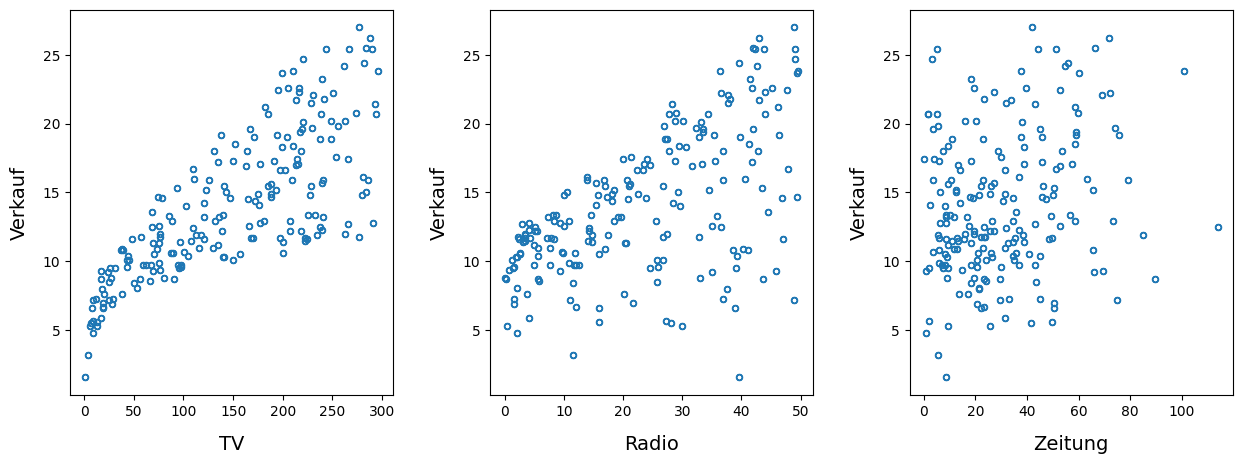

In [ ]:
# Figurobjekt erstellen
fig = plt.figure(figsize=(15,5))

# Achse für das Streudiagramm TV - Verkauf
ax1 = fig.add_subplot(1,3,1)
werbung.plot.scatter(x = "TV", y = "Verkauf", ax = ax1, marker="$\u25EF$")
ax1.set_xlabel("TV",size=14,labelpad=12)
ax1.set_ylabel("Verkauf",size=14,labelpad=10)

# Achse für das Streudiagramm Radio - Verkauf
ax2 = fig.add_subplot(1,3,2)
werbung.plot.scatter(x = "Radio", y = "Verkauf", ax = ax2, marker="$\u25EF$")
ax2.set_xlabel("Radio",size=14,labelpad=12)
ax2.set_ylabel("Verkauf",size=14,labelpad=10)

# Achse für das Streudiagramm Zeitung - Verkauf
ax3 = fig.add_subplot(1,3,3)
werbung.plot.scatter(x = "Zeitung", y = "Verkauf", ax = ax3, marker="$\u25EF$")
ax3.set_xlabel("Zeitung",size=14,labelpad=12)
ax3.set_ylabel("Verkauf",size=14,labelpad=10)

plt.subplots_adjust(wspace=0.3)

plt.show()

Wir schätzen nun die vier **Parameter des multiplen linearen Modells** $$\texttt{Verkauf} = \pmb{a_1}\cdot\texttt{TV} + \pmb{a_2}\cdot\texttt{Radio} + \pmb{a_3}\cdot\texttt{Zeitung} + \pmb{b}$$

In [ ]:
from scipy.optimize import minimize

def model(TV, Radio, Zeitung, a_TV=1, a_Radio=1, a_Zeitung=1, b=0):
    return a_TV*TV + a_Radio*Radio + a_Zeitung*Zeitung + b

def RSS(parameter):
    residuen = werbung["Verkauf"] - model(werbung["TV"],
                                          werbung["Radio"],
                                          werbung["Zeitung"],
                                          a_TV = parameter[0],
                                          a_Radio = parameter[1],
                                          a_Zeitung = parameter[2],
                                          b = parameter[3])
    return (residuen**2).sum()

fit = minimize(RSS, x0=np.zeros(4)+0.1)
fit

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 556.8252629034486
        x: [ 4.576e-02  1.885e-01 -1.038e-03  2.939e+00]
      nit: 7
      jac: [ 0.000e+00  0.000e+00  7.629e-06 -7.629e-06]
 hess_inv: [[ 3.424e-07 -7.868e-08 -5.748e-08 -4.677e-05]
            [-7.868e-08  1.305e-05 -3.133e-06 -1.963e-04]
            [-5.748e-08 -3.133e-06  6.066e-06 -1.040e-04]
            [-4.677e-05 -1.963e-04 -1.040e-04  1.712e-02]]
     nfev: 55
     njev: 11

Mit diesen Parametern können wir die ***Prädiktorfunktion für die Zeilgrösse*** **Verkauf** $$\begin{align*}\texttt{Verkauf} &\;\;=\;\; \texttt{predict}(\texttt{TV},\texttt{Radio},\texttt{Zeitung}) \\ &\;\;=\;\;0.04576\cdot\texttt{TV} + 0.1885\cdot\texttt{Radio} - 0.001038\cdot\texttt{Zeitung} + 2.939\rule{0cm}{1cm}\end{align*}$$
implementieren:

In [ ]:
def predict(TV,Radio,Zeitung):
    return model(TV,Radio,Zeitung,
                 a_TV = fit.x[0],
                 a_Radio = fit.x[1],
                 a_Zeitung = fit.x[2],
                 b = fit.x[3])

predict(20,5,1)

np.float64(4.795799034124643)

Den **Standardfehler der Residuen** (RSE) finden wir mit der **Summe der Residuenquadrate** (RSS), die als Minimalwert in $\texttt{fit.fun}$ gespeichert ist:  

In [ ]:
# Anzahl Prädiktoren
m = 3 

# Residual standard Error 
RSE = np.sqrt(fit.fun / (werbung.shape[0] - (m + 1)))

print(RSE)

1.6855103734166532


Das **Bestimmtheitsmass** $\,\pmb{R^2}\,$ für das Modell finden wir aus dem Quotienten der **mittleren Quadratischen Abweichungen** (MQD) **des Verkaufs** im Modell und in den Daten:

In [ ]:
R_squared = (predict(werbung["TV"],werbung["Radio"],werbung["Zeitung"]).var() / 
             werbung["Verkauf"].var())
print(R_squared)

0.8972098457693326


Das Bestimmtheitsmass sagt uns, dass **ungefähr 90% der mittleren quadratsichen Abweichung** mit dem multiplen linearen Modell erklärt wird.

Ob die ***beobachteten Regressionsparameter*** allenfalls rein zufällig entstanden sind, testen wir für jeden Prädiktor mit der Zielvariablen separat: 

- Die **Nullhypothese** für das **Gewicht** $\,\pmb{a_1}$ des Prädiktors **TV** ist $\quad \pmb{H_0:\; a_1 = 0}$ <br>
mit der **Alternativhypothese** $\quad \pmb{H_1:\; a_1 \neq 0}$
- Die **Nullhypothese** für das **Gewicht** $\,\pmb{a_2}$ des Prädiktors **Radio** ist $\quad \pmb{H_0:\; a_2 = 0}$ <br>
mit der **Alternativhypothese** $\quad \pmb{H_1:\; a_2 \neq 0}$
- Die **Nullhypothese** für das **Gewicht** $\,\pmb{a_3}$ des Prädiktors **Zeitung** ist $\quad \pmb{H_0:\; a_3 = 0}$ <br>
mit der **Alternativhypothese** $\quad \pmb{H_1:\; a_3 \neq 0}$

Mit einem **Permutationstest** können wir die $\pmb{p}$**-Werte** berechnen und diese Hypothesen testen:

In [ ]:
import seaborn as sns
import numpy as np

''' Permutationstest '''

# Anzahl Permutationen
n_permutations = 1000

# Parameter bei den Permutationen
parameterTV_permuted = []
parameterRadio_permuted = []
parameterZeitung_permuted = []

for _ in range(n_permutations):
    # Werte des Merkmals Verkauf zufällig permutieren
    Verkauf_permuted = np.random.permutation(werbung["Verkauf"])

    # die zu minimierende Funktion für die neuen Daten
    def RSS(parameter):
        residuen = Verkauf_permuted - model(werbung["TV"],
                                          werbung["Radio"],
                                          werbung["Zeitung"],
                                          a_TV = parameter[0],
                                          a_Radio = parameter[1],
                                          a_Zeitung = parameter[2],
                                          b = parameter[3])
        return (residuen**2).sum()

    # Lösung des Minimierungsproblems
    fit_permuted = minimize(RSS, x0=np.zeros(4)+0.1)

    # Geschätzte Parameter bei den permutierten Daten
    parameterTV_permuted.append(fit_permuted.x[0])
    parameterRadio_permuted.append(fit_permuted.x[1])
    parameterZeitung_permuted.append(fit_permuted.x[2])

# p-Wert berechnen (zweiseitig)
parameterTV_permuted = np.array(parameterTV_permuted)
p_value_TV = 100*np.mean(np.abs(parameterTV_permuted) >= np.abs(fit.x[0]))

parameterRadio_permuted = np.array(parameterRadio_permuted)
p_value_Radio = 100*np.mean(np.abs(parameterRadio_permuted) >= np.abs(fit.x[1]))

parameterZeitung_permuted = np.array(parameterZeitung_permuted)
p_value_Zeitung = 100*np.mean(np.abs(parameterZeitung_permuted) >= np.abs(fit.x[2]))

print(f"Beobachteter Parameter für TV: {fit.x[0]:.4f}")
print(f"Resampling-basierter p-Wert: {p_value_TV:}")
print(f"Beobachteter Parameter für Radio: {fit.x[1]:.4f}")
print(f"Resampling-basierter p-Wert: {p_value_Radio:}")
print(f"Beobachteter Parameter für Zeitung: {fit.x[2]:.4f}")
print(f"Resampling-basierter p-Wert: {p_value_Zeitung:}")


Beobachteter Parameter für TV: 0.0458
Resampling-basierter p-Wert: 0.0
Beobachteter Parameter für Radio: 0.1885
Resampling-basierter p-Wert: 0.0
Beobachteter Parameter für Zeitung: -0.0010
Resampling-basierter p-Wert: 95.0


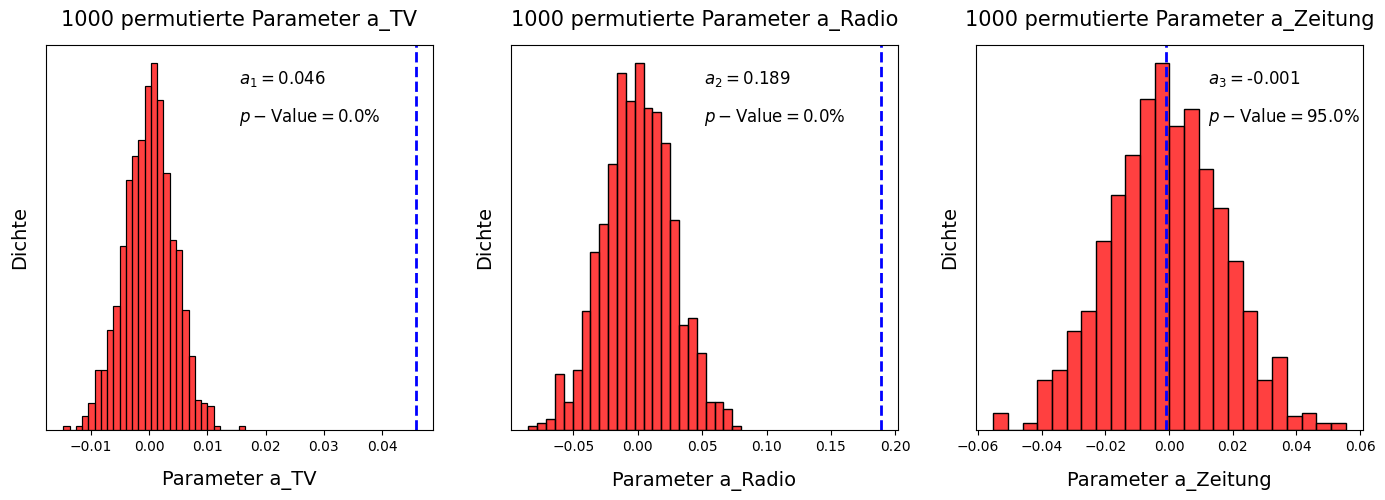

In [ ]:
''' Visualisierung des Testergebnisses '''

# Figurobjekt erstellen
fig = plt.figure(figsize=(17,5))

# Koordinatensystem erstellen
ax1 = fig.add_subplot(1,3,1)

# Dichtediagramm für die Parameter a_TV aus den Permutationen
sns.histplot(parameterTV_permuted,stat="density",ax=ax1,color="red")

# vertikale Linie beim beobachteten Parameter a_TV
ax1.axvline(fit.x[0],color="blue",lw=2,linestyle="dashed")
ax1.text(0.5,0.9,r"$a_1=$"+"{m:1.3f}".format(m=fit.x[0]),
                   fontsize=12,transform=plt.gca().transAxes)

# p-Wert
ax1.text(0.5,0.8,r"$p-$"+"Value"+r"$ = $"+"{p:1.1f}%".format(p=p_value_TV),
                   fontsize=12,transform=plt.gca().transAxes)

# Achsen beschriften
ax1.set_title("1000 permutierte Parameter a_TV", fontsize=15,pad=14)
ax1.set_xlabel("Parameter a_TV",size=14,labelpad=12)
ax1.set_ylabel("Dichte",size=14,labelpad=12)
ax1.set_yticks([])

# Koordinatensystem erstellen
ax2 = fig.add_subplot(1,3,2)

# Dichtediagramm für die Parameter a_Radio aus den Permutationen
sns.histplot(parameterRadio_permuted,stat="density",ax=ax2,color="red")

# vertikale Linie beim beobachteten Parameter a_Radio
ax2.axvline(fit.x[1],color="blue",lw=2,linestyle="dashed")
ax2.text(0.5,0.9,r"$a_2=$"+"{m:1.3f}".format(m=fit.x[1]),
                   fontsize=12,transform=plt.gca().transAxes)

# p-Wert
ax2.text(0.5,0.8,r"$p-$"+"Value"+r"$ = $"+"{p:1.1f}%".format(p=p_value_Radio),
                   fontsize=12,transform=plt.gca().transAxes)

# Achsen beschriften
ax2.set_title("1000 permutierte Parameter a_Radio", fontsize=15,pad=14)
ax2.set_xlabel("Parameter a_Radio",size=14,labelpad=12)
ax2.set_ylabel("Dichte",size=14,labelpad=12)
ax2.set_yticks([])

# Koordinatensystem erstellen
ax3 = fig.add_subplot(1,3,3)

# Dichtediagramm für die Parameter a_Zeitung aus den Permutationen
sns.histplot(parameterZeitung_permuted,stat="density",ax=ax3,color="red")

# vertikale Linie beim beobachteten Parameter a_Zeitung
ax3.axvline(fit.x[2],color="blue",lw=2,linestyle="dashed")
ax3.text(0.6,0.9,r"$a_3=$"+"{m:1.3f}".format(m=fit.x[2]),
                   fontsize=12,transform=plt.gca().transAxes)

# p-Wert
ax3.text(0.6,0.8,r"$p-$"+"Value"+r"$ = $"+"{p:1.1f}%".format(p=p_value_Zeitung),
                   fontsize=12,transform=plt.gca().transAxes)

# Achsen beschriften
ax3.set_title("1000 permutierte Parameter a_Zeitung", fontsize=15,pad=14)
ax3.set_xlabel("Parameter a_Zeitung",size=14,labelpad=12)
ax3.set_ylabel("Dichte",size=14,labelpad=12)
ax3.set_yticks([])

# Figur zeigen
plt.show()

Mit den p-Werten können wir die Hypothesen entscheiden:
- Der beobachtete Parameter $\,\pmb{\hat{a}_1}\,$ beim Prädiktor **TV** kann **nicht durch Zufall erklärt werden**, der p-Wert ist 0%. </br>
Wir **verwerfen die Nullhypothese** und **nehmen die Alternativhypothese an**.
- Der beobachtete Parameter $\,\pmb{\hat{a}_2}\,$ beim Prädiktor **Radio** kann **nicht durch Zufall erklärt werden**, der p-Wert ist 0%. </br>
Wir **verwerfen die Nullhypothese** und **nehmen die Alternativhypothese an**.
- Der beobachtete Parameter $\,\pmb{\hat{a}_3}\,$ beim Prädiktor **Zeitung** kann **durch Zufall erklärt werden**, der p-Wert ist viel grösser als 5%. </br>
Wir **verwerfen die Nullhypothese nicht**.

Wir können auch untersuchen, ob es **Korrelationen zwischen den Prädiktoren** gibt:

In [ ]:
# Korrelationskoeffizienten berechnen
werbung[["TV","Radio","Zeitung"]].corr() 

,TV,Radio,Zeitung
TV,1.000000,0.054809,0.056648
Radio,0.054809,1.000000,0.354104
Zeitung,0.056648,0.354104,1.000000


In der Tat sehen wir eine **schwache positive Korrelation** zwischen dem Prädiktor **Radio** und **Zeitung**, der Korrelationskoeffizient ist $\pmb{r=0.354}$. Das heisst: 
- Je mehr in Radiowerbung investiert wird, desto mehr wird in Zeitungswerbung investiert.

Den Prädiktor **Zeitung** können wir weglassen und das multiple lineare Modell neu nur mit den zwei Prädiktoren **TV** und **Radio** schätzen:

In [ ]:
def model(TV,Radio,a_TV = 1,a_Radio = 1,b = 0):
    return a_TV*TV + a_Radio*Radio + b

def RSS(parameter):
    residuen = werbung["Verkauf"] - model(werbung["TV"],
                                          werbung["Radio"],
                                          a_TV = parameter[0],
                                          a_Radio = parameter[1],
                                          b = parameter[2])
    return (residuen**2).sum()

fit = minimize(RSS, x0=np.zeros(3)+0.2)
fit

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 556.9139800688313
        x: [ 4.575e-02  1.880e-01  2.921e+00]
      nit: 5
      jac: [ 0.000e+00  7.629e-06  0.000e+00]
 hess_inv: [[ 3.419e-07 -1.084e-07 -4.775e-05]
            [-1.084e-07  1.143e-05 -2.500e-04]
            [-4.775e-05 -2.500e-04  1.534e-02]]
     nfev: 92
     njev: 23

Mit diesen neuen Paramtern können wir die ***Prädiktorfunktion für die Zeilgrösse*** **Verkauf** $$\begin{align*}\texttt{Verkauf} &\;\;=\;\; \texttt{predict}(\texttt{TV},\texttt{Radio}) \\ &\;\;=\;\;0.04575\cdot\texttt{TV} + 0.188\cdot\texttt{Radio} + 2.921\rule{0cm}{1cm}\end{align*}$$
nur mit zwei Prädiktoren implementieren:

In [ ]:
def predict2(TV,Radio):
    return model(TV,Radio, a_TV = fit.x[0], a_Radio = fit.x[1], b = fit.x[2])

Nun vergleichen wir den **Standardfehler der Residuen** (RSE) und das **Bestimmtheitsmass** $\,\pmb{R^2}\,$ der zwei Modelle:

In [ ]:
# Anzahl Prädiktoren
m = 2 

# Residual standard Error mit Prädiktoren 
RSE2 = np.sqrt(fit.fun / (werbung.shape[0] - (m+1))) 

# Bestimmtheitsmass mit zwei Prädiktoren
R_squared2 = (predict2(werbung["TV"],werbung["Radio"]).var() / 
              werbung["Verkauf"].var())

# Vergleich
print("-- Multiples lineares Modell mit Prädiktoren TV und Radio --")
print("    R_squared:", round(R_squared2,5)) 
print("          RSE:", round(RSE2,5),end="\n\n") 

print("-- Multiples lineares Modell mit Prädiktoren TV, Radio und Zeitung --")
print("    R_squared:", round(R_squared,5))
print("          RSE:", round(RSE,5)) 

-- Multiples lineares Modell mit Prädiktoren TV und Radio --
    R_squared: 0.89719
          RSE: 1.68136

-- Multiples lineares Modell mit Prädiktoren TV, Radio und Zeitung --
    R_squared: 0.89721
          RSE: 1.68551


Das Modell mit nur den Prädiktoren **TV** und **Radio** hat
- einen geringfügig kleineren $\,\pmb{R^2}\,$ Wert.
- der **Standardfehler der Residuen** (RSE) ist sogar kleiner.

<span style="color:rgb(160,0,86)">**Merksatz:**</span> ***Allgemein wird das Bestimmtheitsmass grösser oder bleigt gleich, wenn wir mehr Prädiktoren im Modell berücksichtigen.***

### <span style="color:rgb(160,0,86)">Was ist eine Kreuzvalidierung?</span>

Die bis anhin betrachteten Regressionsgrössen zur **Beurteilung des Modells** sind allesamt **stichprobenintern** (in-Sample). Sie werden auf Grundlage derselben Daten ermittelt, die zur Anpassung des Modells verwendet werden. 

Es ist sinnvoll **einen Teil** der ursprünglichen Daten **beiseitezulegen**, sie nicht zur Anpassung des Modells zu verwenden und **das Modell** dann auf diesen zurückgelegten Daten **anzuwenden**, um zu sehen, wie gut es abschneidet (out-of-Sample).

Wenn wir eine **Hold-out-Stichprobe für das Testen des Modells** verwenden, sind wir jedoch einer **gewissen Unsicherheit** ausgesetzt, die sich aus der Variabilität dieser kleinen Stichprobe ergibt. Es stellt sich die Frage: 
- Wie unterschiedlich würde das Modell abschneiden, wenn wir **eine andere Hold-out-Stichprobe** für das Testen brauchen.

Das folgende Verfahren dehnt die Idee einer Hold-out-Stichprobe für das Testen des Modells auf **mehrere aufeinanderfolgende Ziehungen von Hold-out-Stichproben** aus:

**Kreuzvalidierungs-Algorithmus**

<tt> <strong>1. Schritt:</strong> Legen Sie $1/k$ der Daten als **Hold-out-Stichprobe** beiseite. </br>
<strong>2. Schritt:</strong> Trainieren Sie das Modell mit den übrigen Daten. </br>
<strong>3. Schritt:</strong> Wenden Sie das Modell auf die **Hold-out-Stichprobe** an und erfassen Sie ein Gütemass zur Bewertung des Modells. </br>
<strong>4. Schritt:</strong> Wiederholen Sie die Schritte 1 bis 3, bis alle Daten jeweils genau einmal in der **Hold-out-Stichprobe** verwendet wurden. </br>
<strong>5. Schritt:</strong> Bilden Sie den Mittelwert der ermittelten Gütemasse.
</tt>

Oft wird der **Root-Mean-Square-Error** $$\textbf{RMSE} = \sqrt{\frac{r_1^2+r_2^2+r_3^2+\ldots+r_{\lfloor n/k\rfloor}^2}{\lfloor n/k\rfloor}} $$ als **Gütemass für den Erfolg** verwendet.

Eine einfache **Umsetzung der Kreuzvalidierung** unterteil zu Beginn die zufällig **gemischten Daten** in ungefähr $\,\pmb{k}\,$ **gleich grosse Teile** und verwendet dann all diese Teile je **genau einmal als Hold-out-Stichprobe**.

- Mit der Methode <tt><strong>sample( )</strong></tt> können wir eine Zufallsstichprobe aus den Zeilen eines DataFrames zeihen. Wenn wir den Parameter <tt><strong>frac=1</strong></tt> setzen, werden 100% der Zeilen gezogen, aber in zufälliger Reihenfolge. Damit erstellen wir eine **zufällige Permuation der Zeilen** des DataFrames.

In [ ]:
# zufällige Reihenfolge
werbung_shuffled = werbung.sample(frac=1)

# in 4 ungefähr gleich große Teile aufteilen
dfs = np.array_split(werbung_shuffled, 4)

print([len(dfs[i]) for i in range(4)])

[50, 50, 50, 50]


Weil wir bei der Kreuzvalidierung das **Modell mehrfach berechnen**, definieren wir die folgende Funktion <tt><strong>fit_and_evaluate()</strong></tt>

In [ ]:
def fit_and_evaluate(werbung_train, werbung_test):
    """
    Trainiert ein lineares Modell auf werbung_train und 
    berechnet RMSE auf werbung_test.
        
    Returns: RMSE (float): Root Mean Squared Error auf den Testdaten
    """
    
    # Modell
    def model(TV, Radio, a_TV=1, a_Radio=1, b=0):
        return a_TV * TV + a_Radio * Radio + b

    # RSS-Funktion
    def RSS(parameter):
        residuen = werbung_train["Verkauf"] - model(werbung_train["TV"],
                                                    werbung_train["Radio"],
                                                    a_TV = parameter[0],
                                                    a_Radio = parameter[1],
                                                    b = parameter[2])
        return (residuen**2).sum()

    # Parameter schätzen
    fit = minimize(RSS, x0=np.zeros(3) + 0.2)

    # Vorhersagefunktion
    def predict(TV, Radio):
        return model(TV,Radio,a_TV=fit.x[0],a_Radio=fit.x[1],b=fit.x[2])

    # RMSE auf Testdaten
    r_square = ( werbung_test["Verkauf"] - 
                 predict(werbung_test["TV"], werbung_test["Radio"]) )**2
    RMSE = np.sqrt(r_square.mean())

    return RMSE

Nun können wir die **Kreuzvalidierung mit den vier Hold-out-Stichporben** durchführen:

In [ ]:
RMSEs = []

for i in range(len(dfs)):
    # Testset ist das i-te DataFrame
    werbung_test = dfs[i]
    
    # Trainingsset: alle anderen DataFrames zusammenfügen
    werbung_train = pd.concat([dfs[j] for j in range(len(dfs)) if j != i])
    
    # RMSE berechnen
    RMSE = fit_and_evaluate(werbung_train, werbung_test)
    
    # Ergebnisse speichern
    RMSEs.append({'test_df': i+1, 'RMSE': RMSE})

# Übersicht der RMSEs
for r in RMSEs:
    print(f"Test-Set df{r['test_df']}: RMSE = {r['RMSE']:.4f}")

# Durchschnitt der RMSEs
print("Mittelwert der RMSE-Werte:", 
      round(np.array([r['RMSE'] for r in RMSEs]).mean(),4))

Test-Set df1: RMSE = 1.5241
Test-Set df2: RMSE = 2.1966
Test-Set df3: RMSE = 1.4290
Test-Set df4: RMSE = 1.5779
Mittelwert der RMSE-Werte: 1.6819


### <span style="color:rgb(160,0,86)">Wie können nicht metrische Merkmale berücksichtigt werden?</span>

- Die Werte eines **ordinalen Merkmales** werden in vernünftige Zahlen übersetzt.
- Die Werte eines **nominalen Merkmals** werden mit **Dummy-Variablen (0/1-Variablen)** abgebildet. Für $k$ Werte braucht es $k-1$ Dummy-Variablen. Ein Wert wird als **Baseline** bezeichnet.

Zum Beispiel können wir das Merkmal **Geschlecht G** mit den zwei Werten ***Frau*** und ***Mann*** mit einer **Dummy-Variable** abbilden:
$$G_{\texttt{Mann}}(x) = \begin{cases}\;1&: \;\text{ wenn } x = \texttt{"Mann"}\\ \;0&: \;\text{ wenn } x = \texttt{"Frau"}\rule{0cm}{1cm}\end{cases}$$
Mit dieser Codierung haben wir den Wert ***Frau*** als **Baseline** gewählt.

Das Merkmal **Blutgruppe BG** mit den drei Werte ***A***, ***B*** und ***AB*** können wir mit zwei Dummy-Variablen abbilden:
$$BG_{\texttt{A}}(x) = \begin{cases}\;1&: \;\text{ wenn } x = \texttt{"A"}\\ \;0&: \;\text{ sonst }\rule{0cm}{1cm}\end{cases}\quad \text{ und }\quad BG_{\texttt{B}}(x) = \begin{cases}\;1&: \;\text{ wenn } x = \texttt{"B"}\\ \;0&: \;\text{ sonst }\rule{0cm}{1cm}\end{cases}$$ Mit dieser Codierung haben wir den Wert ***AB*** als **Baseline** gewählt. In einem multiplen linearen Modell werden nun statt dem Prädiktor **BG** die beiden Dummy-Variablen integriert: $$a_1\cdot BG_{\texttt{A}} + a_2\cdot BG_{\texttt{B}}$$
- Das **Gewicht** $\pmb{a_1}$ beschreibt, welchen Einfluss die Blutgruppe **A** hat.
- Das **Gewicht** $\pmb{a_2}$ beschreibt, welchen Einfluss die Blutgruppe **B** hat.

Auch wenn die Blutgruppe **AB** keine eigene Dummy-Variable hat, ist ihr **Einfluss** trotzdem im Modell enthalten – nur **indirekt über den Parameter** $\,\pmb{b}\,$.

In [ ]:
immo = pd.read_csv("Daten/house_sales.csv",sep="\t")
immo.head(10)

,DocumentDate,SalePrice,PropertyID,PropertyType,ym,zhvi_px,zhvi_idx,AdjSalePrice,NbrLivingUnits,SqFtLot,...,Bathrooms,Bedrooms,BldgGrade,YrBuilt,YrRenovated,TrafficNoise,LandVal,ImpsVal,ZipCode,NewConstruction
1,2014-09-16,280000,1000102,Multiplex,2014-09-01,405100,0.930836,300805.0,2,9373,...,3.00,6,7,1991,0,0,70000,229000,98002,False
2,2006-06-16,1000000,1200013,Single Family,2006-06-01,404400,0.929228,1076162.0,1,20156,...,3.75,4,10,2005,0,0,203000,590000,98166,True
3,2007-01-29,745000,1200019,Single Family,2007-01-01,425600,0.977941,761805.0,1,26036,...,1.75,4,8,1947,0,0,183000,275000,98166,False
4,2008-02-25,425000,2800016,Single Family,2008-02-01,418400,0.961397,442065.0,1,8618,...,3.75,5,7,1966,0,0,104000,229000,98168,False
5,2013-03-29,240000,2800024,Single Family,2013-03-01,351600,0.807904,297065.0,1,8620,...,1.75,4,7,1948,0,0,104000,205000,98168,False
6,2009-03-30,349900,3600090,Townhouse,2009-03-01,369800,0.849724,411781.0,1,1012,...,1.50,2,8,2008,0,0,170000,207000,98144,True
7,2013-08-28,327500,3800004,Single Family,2013-08-01,374300,0.860064,380785.0,1,34465,...,1.50,3,8,1961,0,0,165000,227000,98178,False
8,2007-05-24,347000,3800009,Single Family,2007-05-01,432100,0.992877,349489.0,1,14659,...,1.75,4,7,1963,0,0,115000,154000,98178,False
9,2006-09-22,220400,6600055,Single Family,2006-09-01,414800,0.953125,231239.0,1,5324,...,1.00,2,6,1930,0,3,90000,75000,98032,False
10,2006-08-22,437500,7200080,Multiplex,2006-08-01,411100,0.944623,463148.0,2,10585,...,2.00,4,6,1924,0,0,124000,116000,98055,False


In diesem Datensatz zum Beispiel das Merkmal **PropertyType** nominal und die die drei Werte <tt><strong>Multiplex</strong></tt>, <tt><strong>Singel Family</strong></tt> und <tt><strong>Townhouse</strong></tt>.

Mit der Funnktion <tt><strong>get_dummies( )</strong></tt> können wir die **Dummy-Variablen automatisch erstellen**:

In [ ]:
pd.get_dummies(immo["PropertyType"]).head()

,Multiplex,Single Family,Townhouse
1,True,False,False
2,False,True,False
3,False,True,False
4,False,True,False
5,False,True,False


MIt dem **Parameter** <tt><strong>drop_first=True</strong></tt> können wir die **Baseline setzen**:

In [ ]:
# Erster Wert ist die Basis
pd.get_dummies(immo["PropertyType"],drop_first=True).head()

,Single Family,Townhouse
1,False,False
2,True,False
3,True,False
4,True,False
5,True,False


MIt dem **Parameter** <tt><strong>dtype=int</strong></tt> können wir Dummy-Variable auf die **0/1-Codierung** umstellen:

In [ ]:
# Null-Eins-Codierung
pd.get_dummies(immo["PropertyType"],drop_first=True,dtype=int).head()

,Single Family,Townhouse
1,0,0
2,1,0
3,1,0
4,1,0
5,1,0


Damit können wir aus dem Datensatz **immo** zum Beispiel **die Merkmale** $$\tiny\texttt{"SqFtTotLiving","SqFtLot","Bathrooms","Bedrooms","BldgGrade","PropertyType"}$$ **ausschneiden** und sie mit dem Einführen von Dummy-Variablen **für eine multiple lineare Regression vorbereiten**:

In [ ]:
teilmenge = ["SqFtTotLiving","SqFtLot","Bathrooms","Bedrooms","BldgGrade","PropertyType"]

df = pd.get_dummies(immo[teilmenge],drop_first=True,dtype=int)
df.head()

,SqFtTotLiving,SqFtLot,Bathrooms,Bedrooms,BldgGrade,PropertyType_Single Family,PropertyType_Townhouse
1,2400,9373,3.00,6,7,0,0
2,3764,20156,3.75,4,10,1,0
3,2060,26036,1.75,4,8,1,0
4,3200,8618,3.75,5,7,1,0
5,1720,8620,1.75,4,7,1,0


In [ ]:
predictors = df.columns
predictors

Index(['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms', 'BldgGrade',
       'PropertyType_Single Family', 'PropertyType_Townhouse'],
      dtype='object')

### <span style="color:rgb(160,0,86)">Wie finden wir ein gutes Modell?</span>

Oft stehen sehr viele Merkmale als Prädiktoren für eine Zielvariable zur Verfügung. 
- **Möglichst viele Prädiktoren** zum Modell hinzuzufügen, **bedeutet** jedoch **nicht unbedingt**, dass wir ein **besseres Modell** erhalten.

Wir sollten uns besser bei der Wahl des Modells am **Prinzip der Sparsamkeit** orientieren. 

- <span style="color:rgb(160,0,86)">**Sofern Aspekte von Modellen gleich sind, sollte das einfachere Modell vorgezogen werden!**</span>

Eine Möglichkeit besteht darin, dass wir mit dem einfachsten Modell beginnen  und schrittweise den Prädiktor hinzufügen, der das Modell am besten erweitert (**Vorwärtsselektion**). Wenn die Verbesserung nicht mehr deutlich erkennbar ist, stoppen wir die Erweiterung des Modells:

**Vorwärtsselektions-Algorithmus**

<tt> <strong>1. Schritt:</strong> Wähle das einfache lineare Modell mit dem kleinsten **RSS**-Wert. </br>
<strong>2. Schritt:</strong> Berechne das **Informationskriterium nach Akaike** (*Akaike's Information Criteria*) $$\textbf{AIC} = \underbrace{\textcolor{white}{/}2\cdot \textbf{Anzahl Parameter im Modell\textcolor{white}{/}}}_{\text{Bestrafung: wird grösser}} + \underbrace{\textcolor{white}{/}\pmb{n}\cdot \log(\,\textbf{RSS}/\pmb{n}\,)\textcolor{white}{/}}_{\text{Belohnung: wird kleiner}}$$ wobei $\pmb{n}$ die Anzahl der Daten in der Stichprobe ist. </br>
<strong>3. Schritt:</strong> Ergänze das aktuelle Modell mit einem Prädiktor, so dass der kleinste **RSS**-Wert entsteht. </br>
<strong>4. Schritt:</strong> Wiederhole die Schritte 2 bis 3, bis der **AIC**-Wert nicht mehr abnimmt.
</tt>

Der japanische Statistiker **Hirotsugu Akaike** (1927–2009) hat das Informationskriterium **AIC** entwickelt.
<center>
<img src="Bilder/Akaike.png" width="30%" />
</center>

Zu Beginn gilt:
- Die **Anzahl Parameter im Modell** ist klein und steigt nur langsam.
- Der **Ausdruck** $\pmb{n\cdot\log⁡}(\textbf{RSS}/\pmb{n})$ ist gross, nimmt jedoch mit jedem zusätzlichen Prädiktor typischerweise rasch ab, weil $\,\textbf{RSS}\,$ kleiner wird.

Daher **fällt** der **AIC**-Wert **anfangs**.

Sobald das Modell jedoch gut erklärt ist, führt ein weiterer Prädiktor nur noch zu einer geringen Verringerung der $\,\textbf{RSS}\,$.

Ab einem gewissen Punkt dominiert der Strafterm für die Anzahl Parameter, und der **AIC**-Wert **beginnt wieder zu steigen**.

- An dieser Stelle stoppt der Algorithmus, weil **ein weiterer Prädiktor das Modell nicht mehr verbessert**, sondern **nur überanpasst**.

In [ ]:
def model(A_1,a_1 = 1,b = 0):
    return a_1*A_1 + b

def RSS(parameter):
    residuen = immo["AdjSalePrice"] - model(df[predictors[0]],
                                            a_1 = parameter[0],
                                            b = parameter[1])
    return (residuen**2).sum()

fit = minimize(RSS, x0=[1.000e+00,8.752e-03])
RSS_1 = fit.fun
AIC_1 = 2 * 2 + df.shape[0]*np.log(RSS_1 / df.shape[0])
fit

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 1741349013206110.0
        x: [ 2.934e+02 -4.527e+04]
      nit: 6
      jac: [ 0.000e+00  0.000e+00]
 hess_inv: [[ 2.146e-11 -4.266e-08]
            [-4.266e-08  1.059e-04]]
     nfev: 42
     njev: 14

In [ ]:
print(RSS_1)
print(AIC_1)

1741349013206110.0
568628.453157403


### <span style="color:rgb(160,0,86)">Aufgabe 1</span>

Vervollständigen Sie diese **Vorwärtsselektion**. 

---

### <span style="color:rgb(160,0,86)">Lösungsvorschlag</span>

Wir implementieren zuerst eine **Funktion** <tt><strong>best_next_predictor( )</strong></tt>, die zu einem bestehenden Modell den besten Prädiktor wählt: 

In [ ]:
import numpy as np
from scipy.optimize import minimize

def best_next_predictor(df, response, predictors, features):
    """
    df          : pandas DataFrame
    response    : Zielvariable (string)
    predictors  : Liste aktueller Prädiktoren
    features    : Liste möglicher neuer Prädiktoren als Listen
    
    return      : (bester_prädiktor, minimaler_RSS, AIC_Wert)
    """
    
    best_pred = None
    best_rss = np.inf
    best_aic = np.inf

    for m in features:
        # aktuelles Modell: bekannte Prädiktoren + neuer Kandidat
        X = df[predictors + m].values
        X = np.column_stack([X,np.ones(len(X))])  # Intercept
        
        def model(parameter):
            return np.matmul(X,parameter)
        
        # RSS
        def RSS(parameter):
            residuen = df[response].values - model(parameter)
            return np.sum(residuen**2)

        # Startwerte
        parameter_0 = np.zeros(X.shape[1])

        # Minimierung
        test = False
        while not test:
            fit = minimize(RSS, parameter_0, method="Powell")
            test = fit.success
            parameter_0 = fit.x

        rss = RSS(fit.x)

        # AIC = 2k + n * log(RSS/n)
        n = df.shape[0]
        k = len(fit.x)
        aic = 2*k + n * np.log(rss / n)

        # Beste Auswahl aktualisieren
        if rss < best_rss:
            best_rss = rss
            best_pred = m
            best_aic = aic

    return best_pred, best_rss, best_aic

In [ ]:
teilmenge = ["AdjSalePrice","SqFtTotLiving","SqFtLot","Bathrooms",
             "Bedrooms","BldgGrade","PropertyType"]

df = pd.get_dummies(immo[teilmenge],drop_first=True,dtype=int)

predictors = []
features = [['SqFtTotLiving'],
            ['SqFtLot'],
            ['Bathrooms'],
            ['Bedrooms'],
            ['BldgGrade'],
            ['PropertyType_Single Family','PropertyType_Townhouse']]
predictor_1, rss_1, aic_1 = best_next_predictor(df,"AdjSalePrice",
                                                predictors,
                                                features)

print("bester Prädiktor :", predictor_1,
      "\nRSS              :", rss_1,
      "\nAIC              :", aic_1)

bester Prädiktor : ['SqFtTotLiving'] 
RSS              : 1742474996597250.2 
AIC              : 568643.1181841164


In [ ]:
predictors = ['SqFtTotLiving']
features = [['SqFtLot'],
            ['Bathrooms'],
            ['Bedrooms'],
            ['BldgGrade'],
            ['PropertyType_Single Family','PropertyType_Townhouse']]
predictor_2, rss_2, aic_2 = best_next_predictor(df,"AdjSalePrice",
                                                predictors,
                                                features)

print("bester Prädiktor  :", predictor_2,
      "\nRSS               :", rss_2,
      "\nAIC               :", aic_2,
      "\nAIC_old < AIC_new :",aic_1<aic_2)

bester Prädiktor  : ['BldgGrade'] 
RSS               : 1580967151219826.8 
AIC               : 566438.3597379316 
AIC_old < AIC_new : False


In [ ]:
predictors = ['SqFtTotLiving','BldgGrade']
features = [['SqFtLot'],
            ['Bathrooms'],
            ['Bedrooms'],
            ['PropertyType_Single Family','PropertyType_Townhouse']]
predictor_3, rss_3, aic_3 = best_next_predictor(df,"AdjSalePrice",
                                                predictors,
                                                features)

print("bester Prädiktor  :", predictor_3,
      "\nRSS               :", rss_3,
      "\nAIC               :", aic_3,
      "\nAIC_old < AIC_new :",aic_2<aic_3)

bester Prädiktor  : ['Bedrooms'] 
RSS               : 1550065863023661.2 
AIC               : 565992.5329118075 
AIC_old < AIC_new : False


In [ ]:
predictors = ['SqFtTotLiving','BldgGrade','Bedrooms']
features = [['SqFtLot'],
            ['Bathrooms'],
            ['PropertyType_Single Family','PropertyType_Townhouse']]
predictor_4, rss_4, aic_4 = best_next_predictor(df,"AdjSalePrice",
                                                predictors,
                                                features)

print("bester Prädiktor  :", predictor_4,
      "\nRSS               :", rss_4,
      "\nAIC               :", aic_4,
      "\nAIC_old < AIC_new :",aic_3<aic_4)

bester Prädiktor  : ['Bathrooms'] 
RSS               : 1548137444194786.8 
AIC               : 565966.290708645 
AIC_old < AIC_new : False


In [ ]:
predictors = ['SqFtTotLiving','BldgGrade','Bedrooms','Bathrooms']
features = [['SqFtLot'],
            ['PropertyType_Single Family','PropertyType_Townhouse']]
predictor_5, rss_5, aic_5 = best_next_predictor(df,"AdjSalePrice",
                                                predictors,
                                                features)

print("bester Prädiktor  :", predictor_5,
      "\nRSS               :", rss_5,
      "\nAIC               :", aic_5,
      "\nAIC_old < AIC_new :",aic_4<aic_5)

bester Prädiktor  : ['SqFtLot'] 
RSS               : 1548073087198249.0 
AIC               : 565967.3475769259 
AIC_old < AIC_new : True


Weil der **AIC-Wert** in der 5-ten Iteration wieder ansteigt, haben wir mit der Vorwärtsselektion das folgende **multiple lineare Modell** gefunden:
$$\small\begin{align*}\;\;\texttt{AdjSalePrice} &\;=\; \textbf{predict}(\texttt{SqFtTotLiving},\texttt{BldgGrade},\texttt{Bedrooms},\texttt{Bathrooms})\\ &\;=\; a_1\cdot\texttt{SqFtTotLiving} + a_2\cdot\texttt{BldgGrade} + a_3\cdot\texttt{Bedrooms} + a_4\cdot\texttt{Bathrooms} + b\rule{0cm}{1cm}\end{align*}$$

Die **Gewichte** $\,\pmb{\hat{a}_1}\,$, $\,\pmb{\hat{a}_2}\,$, $\,\pmb{\hat{a}_3}\,$, $\,\pmb{\hat{a}_4}\,$ und $\,\pmb{\hat{b}}\,$ können wir wie gewohnt mit der Methode der kleinsten Quadrate schätzen.  

### <span style="color:rgb(160,0,86)">Aufgabe 2</span>

Machen Sie eine multiple lineare Korrelationsananalyse mit dem Datensatz *Credit.csv* für die Zeilvariable
- die **Kreditwürdigkeit** (*Rating*).
- die **Kontostand bzw. Schuldenstand** (*Balance*) 

---

### <span style="color:rgb(160,0,86)">Lösungsvorschlag</span>

Wir laden die Daten:

In [ ]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize

credit = pd.read_csv("Daten/Credit.csv")
credit.head()

,Unnamed: 0,Income,Limit,Rating,Cards,Age,Education,Gender,Student,Married,Ethnicity,Balance
0,1,14.891,3606,283,2,34,11,Male,No,Yes,Caucasian,333
1,2,106.025,6645,483,3,82,15,Female,Yes,Yes,Asian,903
2,3,104.593,7075,514,4,71,11,Male,No,No,Asian,580
3,4,148.924,9504,681,3,36,11,Female,No,No,Asian,964
4,5,55.882,4897,357,2,68,16,Male,No,Yes,Caucasian,331


Die Spalte ***Unnamed: 0*** können wir lösen:

In [ ]:
credit.drop(columns=["Unnamed: 0"],inplace=True)
credit.head()

,Income,Limit,Rating,Cards,Age,Education,Gender,Student,Married,Ethnicity,Balance
0,14.891,3606,283,2,34,11,Male,No,Yes,Caucasian,333
1,106.025,6645,483,3,82,15,Female,Yes,Yes,Asian,903
2,104.593,7075,514,4,71,11,Male,No,No,Asian,580
3,148.924,9504,681,3,36,11,Female,No,No,Asian,964
4,55.882,4897,357,2,68,16,Male,No,Yes,Caucasian,331


Für die **nominalen Merkmale** führen wir **Dummy-Variablen** ein:

In [ ]:
df = pd.get_dummies(credit,drop_first=True,dtype=int)
df.head()

,Income,Limit,Rating,Cards,Age,Education,Balance,Gender_Female,Student_Yes,Married_Yes,Ethnicity_Asian,Ethnicity_Caucasian
0,14.891,3606,283,2,34,11,333,0,0,1,0,1
1,106.025,6645,483,3,82,15,903,1,1,1,1,0
2,104.593,7075,514,4,71,11,580,0,0,0,1,0
3,148.924,9504,681,3,36,11,964,1,0,0,1,0
4,55.882,4897,357,2,68,16,331,0,0,1,0,1


Nun können wir mit **Vorwärtsselektion** ein Modell für die Zielvariable ***Rating*** berechnen:

In [ ]:
df.columns

Index(['Income', 'Limit', 'Rating', 'Cards', 'Age', 'Education', 'Balance',
       'Gender_Female', 'Student_Yes', 'Married_Yes', 'Ethnicity_Asian',
       'Ethnicity_Caucasian'],
      dtype='object')

In [ ]:
predictors = []
features = [['Income'],
            ['Limit'],
            ['Cards'],
            ['Age'],
            ['Education'], 
            ['Balance'],
            ['Gender_Female'],
            ['Student_Yes'],
            ['Married_Yes'], 
            ['Ethnicity_Asian','Ethnicity_Caucasian']]
predictor_1, rss_1, aic_1 = best_next_predictor(df,"Rating",
                                                predictors,
                                                features)

print("bester Prädiktor :", predictor_1,
      "\nRSS              :", rss_1,
      "\nAIC              :", aic_1)

bester Prädiktor : ['Limit'] 
RSS              : 59515.786372122195 
AIC              : 2005.012930565554


In [ ]:
predictors = ['Limit']
features = [['Income'],
            ['Cards'],
            ['Age'],
            ['Education'], 
            ['Balance'],
            ['Gender_Female'],
            ['Student_Yes'],
            ['Married_Yes'], 
            ['Ethnicity_Asian','Ethnicity_Caucasian']]
predictor_2, rss_2, aic_2 = best_next_predictor(df,"Rating",
                                                predictors,
                                                features)

print("bester Prädiktor  :", predictor_2,
      "\nRSS               :", rss_2,
      "\nAIC               :", aic_2,
      "\nAIC_old < AIC_new :",aic_1<aic_2)

bester Prädiktor  : ['Cards'] 
RSS               : 41819.936612820835 
AIC               : 1865.8655640636093 
AIC_old < AIC_new : False


In [ ]:
predictors = ['Limit','Cards']
features = [['Income'],
            ['Age'],
            ['Education'], 
            ['Balance'],
            ['Gender_Female'],
            ['Student_Yes'],
            ['Married_Yes'], 
            ['Ethnicity_Asian','Ethnicity_Caucasian']]
predictor_3, rss_3, aic_3 = best_next_predictor(df,"Rating",
                                                predictors,
                                                features)

print("bester Prädiktor  :", predictor_3,
      "\nRSS               :", rss_3,
      "\nAIC               :", aic_3,
      "\nAIC_old < AIC_new :",aic_2<aic_3)

bester Prädiktor  : ['Married_Yes'] 
RSS               : 41499.741209433436 
AIC               : 1864.791169269639 
AIC_old < AIC_new : False


In [ ]:
predictors = ['Limit','Cards','Married_Yes']
features = [['Income'],
            ['Age'],
            ['Education'], 
            ['Balance'],
            ['Gender_Female'],
            ['Student_Yes'],
            ['Ethnicity_Asian','Ethnicity_Caucasian']]
predictor_4, rss_4, aic_4 = best_next_predictor(df,"Rating",
                                                predictors,
                                                features)

print("bester Prädiktor  :", predictor_4,
      "\nRSS               :", rss_4,
      "\nAIC               :", aic_4,
      "\nAIC_old < AIC_new :",aic_3<aic_4)

bester Prädiktor  : ['Student_Yes'] 
RSS               : 41163.54686052868 
AIC               : 1863.5375246551125 
AIC_old < AIC_new : False


In [ ]:
predictors = ['Limit','Cards','Married_Yes','Student_Yes']
features = [['Income'],
            ['Age'],
            ['Education'], 
            ['Balance'],
            ['Gender_Female'],
            ['Ethnicity_Asian','Ethnicity_Caucasian']]
predictor_5, rss_5, aic_5 = best_next_predictor(df,"Rating",
                                                predictors,
                                                features)

print("bester Prädiktor  :", predictor_5,
      "\nRSS               :", rss_5,
      "\nAIC               :", aic_5,
      "\nAIC_old < AIC_new :",aic_4<aic_5)

bester Prädiktor  : ['Education'] 
RSS               : 40903.428485314726 
AIC               : 1863.0018469826075 
AIC_old < AIC_new : False


In [ ]:
predictors = ['Limit','Cards','Married_Yes','Student_Yes','Education']
features = [['Income'],
            ['Age'],
            ['Balance'],
            ['Gender_Female'],
            ['Ethnicity_Asian','Ethnicity_Caucasian']]
predictor_6, rss_6, aic_6 = best_next_predictor(df,"Rating",
                                                predictors,
                                                features)

print("bester Prädiktor  :", predictor_6,
      "\nRSS               :", rss_6,
      "\nAIC               :", aic_6,
      "\nAIC_old < AIC_new :",aic_5<aic_6)

bester Prädiktor  : ['Ethnicity_Asian', 'Ethnicity_Caucasian'] 
RSS               : 40684.820169497296 
AIC               : 1864.8583143776477 
AIC_old < AIC_new : True


Weil der **AIC-Wert** in der 6-ten Iteration wieder ansteigt, haben wir mit der Vorwärtsselektion das folgende **multiple lineare Modell** gefunden:
$$\small\begin{align*}\;\;\texttt{Rating} &\;=\; \textbf{predict}(\texttt{Limit},\texttt{Cards},\texttt{MarriedYes},\texttt{StudentYes},\texttt{Education})\\ &\;=\; a_1\cdot\texttt{Limit} + a_2\cdot\texttt{Cards} + a_3\cdot\texttt{MarriedYes} + a_4\cdot\texttt{StudentYes} + a_5\cdot\texttt{Education} + b\rule{0cm}{1cm}\end{align*}$$

Die **Gewichte** $\,\pmb{\hat{a}_1}\,$, $\,\pmb{\hat{a}_2}\,$, $\,\pmb{\hat{a}_3}\,$, $\,\pmb{\hat{a}_4}\,$,  $\,\pmb{\hat{a}_5}\,$ und $\,\pmb{\hat{b}}\,$ können wir  mit der Methode der kleinsten Quadrate schätzen:  

In [ ]:
def model(Limit,Cards,Married_Yes,Student_Yes,Education,
          a_Limit = 1,
          a_Cards = 1,
          a_Married_Yes = 1,
          a_Student_Yes = 1,
          a_Education = 1,
          b = 0):
    return (a_Limit * Limit +
            a_Cards * Cards + 
            a_Married_Yes * Married_Yes + 
            a_Student_Yes * Student_Yes +
            a_Education * Education +
            b)

def RSS(parameter):
    residuen = df["Rating"] - model(df["Limit"],
                                    df["Cards"],
                                    df["Married_Yes"],
                                    df["Student_Yes"],
                                    df["Education"],
                                    a_Limit = parameter[0],
                                    a_Cards = parameter[1],
                                    a_Married_Yes = parameter[2],
                                    a_Student_Yes = parameter[3],
                                    a_Education = parameter[4],
                                    b = parameter[5])
    return (residuen**2).sum()

fit = minimize(RSS, x0=np.zeros(6),method="Powell")
print(fit.success)

def predict_Rating(Limit,Cards,Married_Yes,Student_Yes,Education):
    return model(Limit,Cards,Married_Yes,Student_Yes,Education,
                 a_Limit = fit.x[0],
                 a_Cards = fit.x[1],
                 a_Married_Yes = fit.x[2],
                 a_Student_Yes = fit.x[3],
                 a_Education = fit.x[4],
                 b = fit.x[5])

True


Mit dem $\pmb{R^2}$**-Wert** können wir das Modell beurteilen:

In [ ]:
R_squared = (predict_Rating(df["Limit"],
                            df["Cards"],
                            df["Married_Yes"],
                            df["Student_Yes"],
                            df["Education"]).var() / 
              df["Rating"].var())

print("Bestimmtheitsmass R^2 =",R_squared)

Bestimmtheitsmass R^2 = 0.9957249865451812


Wir erklären also ca. 99.5% der Variabilität in **Rating** mit dem Modell.

Ob die ***beobachteten Regressionsparameter*** allenfalls rein zufällig entstanden sind, testen wir für jeden Prädiktor mit der Zielvariablen separat: 

- Die **Nullhypothese** für das **Gewicht** $\,\pmb{a_1}$ des Prädiktors **Limit** ist $\quad \pmb{H_0:\; a_1 = 0}$ <br>
mit der **Alternativhypothese** $\quad \pmb{H_1:\; a_1 \neq 0}$
- Die **Nullhypothese** für das **Gewicht** $\,\pmb{a_2}$ des Prädiktors **Cards** ist $\quad \pmb{H_0:\; a_2 = 0}$ <br>
mit der **Alternativhypothese** $\quad \pmb{H_1:\; a_2 \neq 0}$
- Die **Nullhypothese** für das **Gewicht** $\,\pmb{a_3}$ des Prädiktors **MarriedYes** ist $\quad \pmb{H_0:\; a_3 = 0}$ <br>
mit der **Alternativhypothese** $\quad \pmb{H_1:\; a_3 \neq 0}$
- Die **Nullhypothese** für das **Gewicht** $\,\pmb{a_4}$ des Prädiktors **StudentYes** ist $\quad \pmb{H_0:\; a_4 = 0}$ <br>
mit der **Alternativhypothese** $\quad \pmb{H_1:\; a_4 \neq 0}$
- Die **Nullhypothese** für das **Gewicht** $\,\pmb{a_5}$ des Prädiktors **Education** ist $\quad \pmb{H_0:\; a_5 = 0}$ <br>
mit der **Alternativhypothese** $\quad \pmb{H_1:\; a_5 \neq 0}$

Mit einem **Permutationstest** können wir die $\pmb{p}$**-Werte** berechnen und diese Hypothesen testen:

In [ ]:
import numpy as np

''' Permutationstest '''

# Anzahl Permutationen
n_permutations = 1000

# Parameter bei den Permutationen
parameterLimit_permuted = []
parameterCards_permuted = []
parameterMarriedYes_permuted = []
parameterStudentYes_permuted = []
parameterEducation_permuted = []

for i in range(n_permutations):
    if i % 100 == 0:
        print("Stand:",i)
    # Werte des Merkmals Rating zufällig permutieren
    Rating_permuted = np.random.permutation(df["Rating"])

    # die zu minimierende Funktion für die neuen Daten
    def RSS(parameter):
        residuen = Rating_permuted - model(df["Limit"],
                                           df["Cards"],
                                           df["Married_Yes"],
                                           df["Student_Yes"],
                                           df["Education"],
                                           a_Limit = parameter[0],
                                           a_Cards = parameter[1],
                                           a_Married_Yes = parameter[2],
                                           a_Student_Yes = parameter[3],
                                           a_Education = parameter[4],
                                           b = parameter[5])
        return (residuen**2).sum()

    # Lösung des Minimierungsproblems
    parameter_0 = np.zeros(6)
    test = False
    while not test:
        fit_permuted = minimize(RSS, x0=parameter_0,method="Powell")
        parameter_0 = fit_permuted.x
        if fit_permuted.success:
            test = True

    # Geschätzte Parameter bei den permutierten Daten
    parameterLimit_permuted.append(fit_permuted.x[0])
    parameterCards_permuted.append(fit_permuted.x[1])
    parameterMarriedYes_permuted.append(fit_permuted.x[2])
    parameterStudentYes_permuted.append(fit_permuted.x[3])
    parameterEducation_permuted.append(fit_permuted.x[4])

# p-Wert berechnen (zweiseitig)
parameterLimit_permuted = np.array(parameterLimit_permuted)
p_value_Limit = 100*np.mean(np.abs(parameterLimit_permuted) >= np.abs(fit.x[0]))

parameterCards_permuted = np.array(parameterCards_permuted)
p_value_Cards = 100*np.mean(np.abs(parameterCards_permuted) >= np.abs(fit.x[1]))

parameterMarriedYes_permuted = np.array(parameterMarriedYes_permuted)
p_value_MarriedYes = 100*np.mean(np.abs(parameterMarriedYes_permuted) >= np.abs(fit.x[2]))

parameterStudentYes_permuted = np.array(parameterStudentYes_permuted)
p_value_StudentYes = 100*np.mean(np.abs(parameterStudentYes_permuted) >= np.abs(fit.x[3]))

parameterEducation_permuted = np.array(parameterEducation_permuted)
p_value_Education = 100*np.mean(np.abs(parameterEducation_permuted) >= np.abs(fit.x[4]))


print(f"Beobachteter Parameter für Limit: {fit.x[0]:.4f}")
print(f"Resampling-basierter p-Wert: {p_value_Limit:}")
print(f"Beobachteter Parameter für Cards: {fit.x[1]:.4f}")
print(f"Resampling-basierter p-Wert: {p_value_Cards:}")
print(f"Beobachteter Parameter für MarriedYes: {fit.x[2]:.4f}")
print(f"Resampling-basierter p-Wert: {p_value_MarriedYes:}")
print(f"Beobachteter Parameter für StudentYes: {fit.x[3]:.4f}")
print(f"Resampling-basierter p-Wert: {p_value_StudentYes:}")
print(f"Beobachteter Parameter für Education: {fit.x[4]:.4f}")
print(f"Resampling-basierter p-Wert: {p_value_Education:}")

Stand: 0
Stand: 100
Stand: 200
Stand: 300
Stand: 400
Stand: 500
Stand: 600
Stand: 700
Stand: 800
Stand: 900
Beobachteter Parameter für Limit: 0.0668
Resampling-basierter p-Wert: 0.0
Beobachteter Parameter für Cards: 4.8528
Resampling-basierter p-Wert: 36.6
Beobachteter Parameter für MarriedYes: 2.2002
Resampling-basierter p-Wert: 89.3
Beobachteter Parameter für StudentYes: 3.0743
Resampling-basierter p-Wert: 91.2
Beobachteter Parameter für Education: -0.2597
Resampling-basierter p-Wert: 91.7


Mit den p-Werten können wir die Hypothesen entscheiden:
- Der beobachtete Parameter $\,\pmb{\hat{a}_1}\,$ beim Prädiktor **Limit** kann **nicht durch Zufall erklärt werden**, der p-Wert ist 0%. </br>
Wir **verwerfen die Nullhypothese** und **nehmen die Alternativhypothese an**.
- Der beobachtete Parameter $\,\pmb{\hat{a}_2}\,$ beim Prädiktor **Cards** kann **durch Zufall erklärt werden**, der p-Wert ist viel grösser als 5%. </br>
Wir **verwerfen die Nullhypothese nicht**.
- Der beobachtete Parameter $\,\pmb{\hat{a}_3}\,$ beim Prädiktor **MarriedYes** kann **durch Zufall erklärt werden**, der p-Wert ist viel grösser als 5%. </br>
Wir **verwerfen die Nullhypothese nicht**.
- Der beobachtete Parameter $\,\pmb{\hat{a}_4}\,$ beim Prädiktor **StudentYes** kann **durch Zufall erklärt werden**, der p-Wert ist viel grösser als 5%. </br>
Wir **verwerfen die Nullhypothese nicht**.
- Der beobachtete Parameter $\,\pmb{\hat{a}_5}\,$ beim Prädiktor **Education** kann **durch Zufall erklärt werden**, der p-Wert ist viel grösser als 5%. </br>
Wir **verwerfen die Nullhypothese nicht**.


Wir können auch untersuchen, ob es **Korrelationen zwischen den Merkmalen** gibt:

In [ ]:
df.corr()

,Income,Limit,Rating,Cards,Age,Education,Balance,Gender_Female,Student_Yes,Married_Yes,Ethnicity_Asian,Ethnicity_Caucasian
Income,1.000000,0.792088,0.791378,-0.018273,0.175338,-0.027692,0.463656,-0.010738,0.019632,0.035652,-0.017137,-0.019701
Limit,0.792088,1.000000,0.996880,0.010231,0.100888,-0.023549,0.861697,0.009397,-0.006015,0.031155,-0.032427,-0.003081
Rating,0.791378,0.996880,1.000000,0.053239,0.103165,-0.030136,0.863625,0.008885,-0.002028,0.036751,-0.035999,-0.001070
Cards,-0.018273,0.010231,0.053239,1.000000,0.042948,-0.051084,0.086456,-0.022658,-0.026164,-0.009695,0.005591,-0.005631
Age,0.175338,0.100888,0.103165,0.042948,1.000000,0.003619,0.001835,0.004015,-0.029844,-0.073136,-0.059623,-0.000822
Education,-0.027692,-0.023549,-0.030136,-0.051084,0.003619,1.000000,-0.008062,-0.005049,0.072085,0.048911,0.029586,-0.037725
Balance,0.463656,0.861697,0.863625,0.086456,0.001835,-0.008062,1.000000,0.021474,0.259018,-0.005673,-0.009812,-0.003288
Gender_Female,-0.010738,0.009397,0.008885,-0.022658,0.004015,-0.005049,0.021474,1.000000,0.055034,0.012452,0.025425,-0.009831
Student_Yes,0.019632,-0.006015,-0.002028,-0.026164,-0.029844,0.072085,0.259018,0.055034,1.000000,-0.076974,0.053534,-0.048334
Married_Yes,0.035652,0.031155,0.036751,-0.009695,-0.073136,0.048911,-0.005673,0.012452,-0.076974,1.000000,0.088595,0.011418


**In der Tat!** Es besteht eine **fast perfekte positive Korrelation** zwischen ***Rating*** und ***Limit***. Daher reicht eine einfache lineare Regression:

In [ ]:
def model(A_1,a_1 = 1,b = 0):
    return a_1*A_1 + b

def RSS(parameter):
    residuen = df["Rating"] - model(df["Limit"],
                                    a_1 = parameter[0],
                                    b = parameter[1])
    return (residuen**2).sum()

fit_einfach = minimize(RSS, x0=np.array([0,0]))

def predict_einfach(Limit):
    return model(Limit,fit_einfach.x[0],fit_einfach.x[1])

R_squared_einfach = (predict_einfach(df["Limit"]).var() / df["Rating"].var())

print("Bestimmtheitsmass R^2 multiple lineare Regression =",round(R_squared,4))
print("Bestimmtheitsmass R^2 einfache lineare Regression =",round(R_squared_einfach,4))

Bestimmtheitsmass R^2 multiple lineare Regression = 0.9957
Bestimmtheitsmass R^2 einfache lineare Regression = 0.9938


Der Unterschied im $\pmb{R^2}$**-Wert** für das einfache und das multiple Modell ist marginal...

---

Mit **Vorwärtsselektion** können wir analog ein Modell für die Zielvariable ***Balance*** berechnen:

In [ ]:
predictors = []
features = [['Income'],
            ['Limit'],
            ['Cards'],
            ['Age'],
            ['Education'], 
            ['Rating'],
            ['Gender_Female'],
            ['Student_Yes'],
            ['Married_Yes'], 
            ['Ethnicity_Asian','Ethnicity_Caucasian']]
predictor_1, rss_1, aic_1 = best_next_predictor(df,"Balance",
                                                predictors,
                                                features)

print("bester Prädiktor :", predictor_1,
      "\nRSS              :", rss_1,
      "\nAIC              :", aic_1)

bester Prädiktor : ['Rating'] 
RSS              : 21524043.198470607 
AIC              : 4361.286643788912


In [ ]:
predictors = ['Rating']
features = [['Income'],
            ['Limit'],
            ['Cards'],
            ['Age'],
            ['Education'], 
            ['Gender_Female'],
            ['Student_Yes'],
            ['Married_Yes'], 
            ['Ethnicity_Asian','Ethnicity_Caucasian']]
predictor_2, rss_2, aic_2 = best_next_predictor(df,"Balance",
                                                predictors,
                                                features)

print("bester Prädiktor  :", predictor_2,
      "\nRSS               :", rss_2,
      "\nAIC               :", aic_2,
      "\nAIC_old < AIC_new :",aic_1<aic_2)

bester Prädiktor  : ['Income'] 
RSS               : 10532541.290169619 
AIC               : 4077.406258393041 
AIC_old < AIC_new : False


In [ ]:
predictors = ['Rating','Income']
features = [['Limit'],
            ['Cards'],
            ['Age'],
            ['Education'], 
            ['Gender_Female'],
            ['Student_Yes'],
            ['Married_Yes'], 
            ['Ethnicity_Asian','Ethnicity_Caucasian']]
predictor_3, rss_3, aic_3 = best_next_predictor(df,"Balance",
                                                predictors,
                                                features)

print("bester Prädiktor  :", predictor_3,
      "\nRSS               :", rss_3,
      "\nAIC               :", aic_3,
      "\nAIC_old < AIC_new :",aic_2<aic_3)

bester Prädiktor  : ['Student_Yes'] 
RSS               : 4227219.311057325 
AIC               : 3714.236165790972 
AIC_old < AIC_new : False


In [ ]:
predictors = ['Rating','Income','Student_Yes']
features = [['Limit'],
            ['Cards'],
            ['Age'],
            ['Education'], 
            ['Gender_Female'],
            ['Married_Yes'],
            ['Ethnicity_Asian','Ethnicity_Caucasian']]
predictor_4, rss_4, aic_4 = best_next_predictor(df,"Balance",
                                                predictors,
                                                features)

print("bester Prädiktor  :", predictor_4,
      "\nRSS               :", rss_4,
      "\nAIC               :", aic_4,
      "\nAIC_old < AIC_new :",aic_3<aic_4)

bester Prädiktor  : ['Limit'] 
RSS               : 4061116.7709743767 
AIC               : 3700.201605355388 
AIC_old < AIC_new : False


In [ ]:
predictors = ['Rating','Income','Student_Yes','Limit']
features = [['Cards'],
            ['Age'],
            ['Education'], 
            ['Gender_Female'],
            ['Married_Yes'],
            ['Ethnicity_Asian','Ethnicity_Caucasian']]
predictor_5, rss_5, aic_5 = best_next_predictor(df,"Balance",
                                                predictors,
                                                features)

print("bester Prädiktor  :", predictor_5,
      "\nRSS               :", rss_5,
      "\nAIC               :", aic_5,
      "\nAIC_old < AIC_new :",aic_4<aic_5)

bester Prädiktor  : ['Cards'] 
RSS               : 3892961.9699172517 
AIC               : 3685.286524239926 
AIC_old < AIC_new : False


In [ ]:
predictors = ['Rating','Income','Student_Yes','Limit','Cards']
features = [['Age'],
            ['Education'], 
            ['Gender_Female'],
            ['Married_Yes'],
            ['Ethnicity_Asian','Ethnicity_Caucasian']]
predictor_6, rss_6, aic_6 = best_next_predictor(df,"Balance",
                                                predictors,
                                                features)

print("bester Prädiktor  :", predictor_6,
      "\nRSS               :", rss_6,
      "\nAIC               :", aic_6,
      "\nAIC_old < AIC_new :",aic_5<aic_6)

bester Prädiktor  : ['Gender_Female'] 
RSS               : 3971265.833194472 
AIC               : 3695.252361761916 
AIC_old < AIC_new : True


Weil der **AIC-Wert** in der 6-ten Iteration wieder ansteigt, haben wir mit der Vorwärtsselektion das folgende **multiple lineare Modell** gefunden:
$$\small\begin{align*}\;\;\texttt{Balance} &\;=\; \textbf{predict}(\texttt{Rating},\texttt{Income},\texttt{StudentYes},\texttt{Limit},\texttt{Cards})\\ &\;=\; a_1\cdot\texttt{Rating} + a_2\cdot\texttt{Income} + a_3\cdot\texttt{StudentYes} + a_4\cdot\texttt{Limit} + a_5\cdot\texttt{Cards} + b\rule{0cm}{1cm}\end{align*}$$

Die **Gewichte** $\,\pmb{\hat{a}_1}\,$, $\,\pmb{\hat{a}_2}\,$, $\,\pmb{\hat{a}_3}\,$, $\,\pmb{\hat{a}_4}\,$,  $\,\pmb{\hat{a}_5}\,$ und $\,\pmb{\hat{b}}\,$ können wir  mit der Methode der kleinsten Quadrate schätzen:  

In [ ]:
def model(Rating,Income,Student_Yes,Limit,Cards,
          a_Rating = 1,
          a_Income = 1,
          a_Student_Yes = 1,
          a_Limit = 1,
          a_Cards = 1,
          b = 0):
    return (a_Rating * Rating +
            a_Income * Income + 
            a_Student_Yes * Student_Yes + 
            a_Limit * Limit +
            a_Cards * Cards +
            b)

def RSS(parameter):
    residuen = df["Balance"] - model(df["Rating"],
                                    df["Income"],
                                    df["Student_Yes"],
                                    df["Limit"],
                                    df["Cards"],
                                    a_Rating = parameter[0],
                                    a_Income = parameter[1],
                                    a_Student_Yes = parameter[2],
                                    a_Limit = parameter[3],
                                    a_Cards = parameter[4],
                                    b = parameter[5])
    return (residuen**2).sum()

fit = minimize(RSS, x0=np.zeros(6),method="Powell")
print(fit.success)

def predict_Balance(Rating,Income,Student_Yes,Limit,Cards):
    return model(Rating,Income,Student_Yes,Limit,Cards,
                 a_Rating = fit.x[0],
                 a_Income = fit.x[1],
                 a_Student_Yes = fit.x[2],
                 a_Limit = fit.x[3],
                 a_Cards = fit.x[4],
                 b = fit.x[5])

True


Ob die ***beobachteten Regressionsparameter*** allenfalls rein zufällig entstanden sind, testen wir für jeden Prädiktor mit der Zielvariablen separat: 

- Die **Nullhypothese** für das **Gewicht** $\,\pmb{a_1}$ des Prädiktors **Rating** ist $\quad \pmb{H_0:\; a_1 = 0}$ <br>
mit der **Alternativhypothese** $\quad \pmb{H_1:\; a_1 \neq 0}$
- Die **Nullhypothese** für das **Gewicht** $\,\pmb{a_2}$ des Prädiktors **Income** ist $\quad \pmb{H_0:\; a_2 = 0}$ <br>
mit der **Alternativhypothese** $\quad \pmb{H_1:\; a_2 \neq 0}$
- Die **Nullhypothese** für das **Gewicht** $\,\pmb{a_3}$ des Prädiktors **StudentYes** ist $\quad \pmb{H_0:\; a_3 = 0}$ <br>
mit der **Alternativhypothese** $\quad \pmb{H_1:\; a_3 \neq 0}$
- Die **Nullhypothese** für das **Gewicht** $\,\pmb{a_4}$ des Prädiktors **Limit** ist $\quad \pmb{H_0:\; a_4 = 0}$ <br>
mit der **Alternativhypothese** $\quad \pmb{H_1:\; a_4 \neq 0}$
- Die **Nullhypothese** für das **Gewicht** $\,\pmb{a_5}$ des Prädiktors **Cards** ist $\quad \pmb{H_0:\; a_5 = 0}$ <br>
mit der **Alternativhypothese** $\quad \pmb{H_1:\; a_5 \neq 0}$

Mit einem **Permutationstest** können wir die $\pmb{p}$**-Werte** berechnen und diese Hypothesen testen:

In [ ]:
import numpy as np

''' Permutationstest '''

# Anzahl Permutationen
n_permutations = 1000

# Parameter bei den Permutationen
parameterRating_permuted = []
parameterIncome_permuted = []
parameterStudentYes_permuted = []
parameterLimit_permuted = []
parameterCards_permuted = []

for i in range(n_permutations):
    if i % 100 == 0:
        print("Stand:",i)
    # Werte des Merkmals Rating zufällig permutieren
    Balance_permuted = np.random.permutation(df["Balance"])

    # die zu minimierende Funktion für die neuen Daten
    def RSS(parameter):
        residuen = Balance_permuted - model(df["Rating"],
                                           df["Income"],
                                           df["Student_Yes"],
                                           df["Limit"],
                                           df["Cards"],
                                           a_Rating = parameter[0],
                                           a_Income = parameter[1],
                                           a_Student_Yes = parameter[2],
                                           a_Limit = parameter[3],
                                           a_Cards = parameter[4],
                                           b = parameter[5])
        return (residuen**2).sum()

    # Lösung des Minimierungsproblems
    parameter_0 = np.zeros(6)
    test = False
    while not test:
        fit_permuted = minimize(RSS, x0=parameter_0,method="Powell")
        parameter_0 = fit_permuted.x
        if fit_permuted.success:
            test = True

    # Geschätzte Parameter bei den permutierten Daten
    parameterRating_permuted.append(fit_permuted.x[0])
    parameterIncome_permuted.append(fit_permuted.x[1])
    parameterStudentYes_permuted.append(fit_permuted.x[2])
    parameterLimit_permuted.append(fit_permuted.x[3])
    parameterCards_permuted.append(fit_permuted.x[4])

# p-Wert berechnen (zweiseitig)
parameterRating_permuted = np.array(parameterRating_permuted)
p_value_Rating = 100*np.mean(np.abs(parameterRating_permuted) >= np.abs(fit.x[0]))

parameterIncome_permuted = np.array(parameterIncome_permuted)
p_value_Income = 100*np.mean(np.abs(parameterIncome_permuted) >= np.abs(fit.x[1]))

parameterStudentYes_permuted = np.array(parameterStudentYes_permuted)
p_value_StudentYes = 100*np.mean(np.abs(parameterStudentYes_permuted) >= np.abs(fit.x[2]))

parameterLimitYes_permuted = np.array(parameterLimit_permuted)
p_value_Limit = 100*np.mean(np.abs(parameterLimit_permuted) >= np.abs(fit.x[3]))

parameterCards_permuted = np.array(parameterCards_permuted)
p_value_Cards = 100*np.mean(np.abs(parameterCards_permuted) >= np.abs(fit.x[4]))


print(f"Beobachteter Parameter für Rating: {fit.x[0]:.4f}")
print(f"Resampling-basierter p-Wert: {p_value_Rating:}")
print(f"Beobachteter Parameter für Income: {fit.x[1]:.4f}")
print(f"Resampling-basierter p-Wert: {p_value_Income:}")
print(f"Beobachteter Parameter für StudentYes: {fit.x[2]:.4f}")
print(f"Resampling-basierter p-Wert: {p_value_StudentYes:}")
print(f"Beobachteter Parameter für Limit: {fit.x[3]:.4f}")
print(f"Resampling-basierter p-Wert: {p_value_Limit:}")
print(f"Beobachteter Parameter für Cards: {fit.x[4]:.4f}")
print(f"Resampling-basierter p-Wert: {p_value_Cards:}")

Stand: 0
Stand: 100
Stand: 200
Stand: 300
Stand: 400
Stand: 500
Stand: 600
Stand: 700
Stand: 800
Stand: 900
Beobachteter Parameter für Rating: 1.8854
Resampling-basierter p-Wert: 0.0
Beobachteter Parameter für Income: -7.9384
Resampling-basierter p-Wert: 0.0
Beobachteter Parameter für StudentYes: 424.5221
Resampling-basierter p-Wert: 0.0
Beobachteter Parameter für Limit: 0.1416
Resampling-basierter p-Wert: 0.0
Beobachteter Parameter für Cards: 13.5818
Resampling-basierter p-Wert: 42.199999999999996


Mit den p-Werten können wir die Hypothesen entscheiden:
- Der beobachtete Parameter $\,\pmb{\hat{a}_1}\,$ beim Prädiktor **Rating** kann **nicht durch Zufall erklärt werden**, der p-Wert ist 0%. </br>
Wir **verwerfen die Nullhypothese** und **nehmen die Alternativhypothese an**.
- Der beobachtete Parameter $\,\pmb{\hat{a}_2}\,$ beim Prädiktor **Income** kann **nicht durch Zufall erklärt werden**, der p-Wert ist 0%. </br>
Wir **verwerfen die Nullhypothese** und **nehmen die Alternativhypothese an**.
- Der beobachtete Parameter $\,\pmb{\hat{a}_3}\,$ beim Prädiktor **StudentYes** kann **nicht durch Zufall erklärt werden**, der p-Wert ist 0%. </br>
Wir **verwerfen die Nullhypothese** und **nehmen die Alternativhypothese an**.
- Der beobachtete Parameter $\,\pmb{\hat{a}_4}\,$ beim Prädiktor **Limit** kann **nicht durch Zufall erklärt werden**, der p-Wert ist 0%. </br>
Wir **verwerfen die Nullhypothese** und **nehmen die Alternativhypothese an**.
- Der beobachtete Parameter $\,\pmb{\hat{a}_5}\,$ beim Prädiktor **Cards** kann **durch Zufall erklärt werden**, der p-Wert ist viel grösser als 5%. </br>
Wir **verwerfen die Nullhypothese nicht**.



Wir können mit dem folgenden **multiple lineare Modell** die Zeilvariable **Balance** schätzen:
$$\small\begin{align*}\;\;\texttt{Balance} &\;=\; \textbf{predict}(\texttt{Rating},\texttt{Income},\texttt{StudentYes},\texttt{Limit},\texttt{Cards})\\ &\;=\; a_1\cdot\texttt{Rating} + a_2\cdot\texttt{Income} + a_3\cdot\texttt{StudentYes} + a_4\cdot\texttt{Limit} + b\rule{0cm}{1cm}\end{align*}$$

Für die Gewichte gilt:

In [ ]:
def model(Rating,Income,Student_Yes,Limit,a_Rating = 1,
                                          a_Income = 1,
                                          a_Student_Yes = 1,
                                          a_Limit = 1,
                                          b = 0):
    return (a_Rating * Rating +
            a_Income * Income + 
            a_Student_Yes * Student_Yes + 
            a_Limit * Limit + 
            b)


def RSS(parameter):
    residuen = df["Balance"] - model(df["Rating"],
                                    df["Income"],
                                    df["Student_Yes"],
                                    df["Limit"],
                                    a_Rating = parameter[0],
                                    a_Income = parameter[1],
                                    a_Student_Yes = parameter[2],
                                    a_Limit = parameter[3],
                                    b = parameter[4])
    return (residuen**2).sum()

fit = minimize(RSS, x0=np.zeros(5),method="Powell")
print(fit.success)

def predict_Balance(Rating,Income,Student_Yes,Limit):
    return model(Rating,Income,Student_Yes,Limit,
                 a_Rating = fit.x[0],
                 a_Income = fit.x[1],
                 a_Student_Yes = fit.x[2],
                 a_Limit = fit.x[3],
                 b = fit.x[4])

True


Mit dem $\pmb{R^2}$**-Wert** können wir das Modell beurteilen:

In [ ]:
R_squared = (predict_Balance(df["Rating"],
                            df["Income"],
                            df["Student_Yes"],
                            df["Limit"]).var() / 
              df["Balance"].var())

print("Bestimmtheitsmass R^2 =",R_squared)

Bestimmtheitsmass R^2 = 0.9516098480054331


Wir erklären also ca. 95.2% der Variabilität in **Balance** mit dem Modell.

![HSLU](Bilder/LogoHSLU.png)